# Sanity Check — agent_features

Verifica qualità del dataset prima di procedere con ML:
1. Copertura (NULL per colonna)
2. Distribuzioni delle feature principali
3. Correlazioni
4. Outlier

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

conn = sqlite3.connect("../data/moltbook.db")
df = pd.read_sql("SELECT * FROM agent_features", conn)

print(f"Righe totali: {len(df)}")
print(f"Colonne: {len(df.columns)}")

Righe totali: 27107
Colonne: 27


## 1. Copertura — NULL per colonna

In [2]:
# Conta NULL e percentuale per ogni colonna
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(1)

coverage = pd.DataFrame({
    "non_null": len(df) - null_counts,
    "null": null_counts,
    "null_%": null_pct
}).sort_values("null_%", ascending=False)

print(coverage.to_string())

                     non_null   null  null_%
self_reply_rate          5042  22065    81.4
burstiness_posts         7653  19454    71.8
in_degree                9096  18011    66.4
out_degree               9096  18011    66.4
pagerank                 9096  18011    66.4
betweenness              9096  18011    66.4
local_clustering         9096  18011    66.4
egonet_size              9096  18011    66.4
egonet_density           9096  18011    66.4
reciprocity_local        9096  18011    66.4
mean_thread_depth       16891  10216    37.7
mean_post_length        20545   6562    24.2
std_post_length         20545   6562    24.2
reply_to_post_ratio     20771   6336    23.4
type_token_ratio        26942    165     0.6
hour_entropy            27107      0     0.0
active_days             27107      0     0.0
n_posts                 27107      0     0.0
feature_version         27107      0     0.0
agent_id                27107      0     0.0
computed_at             27107      0     0.0
last_activ

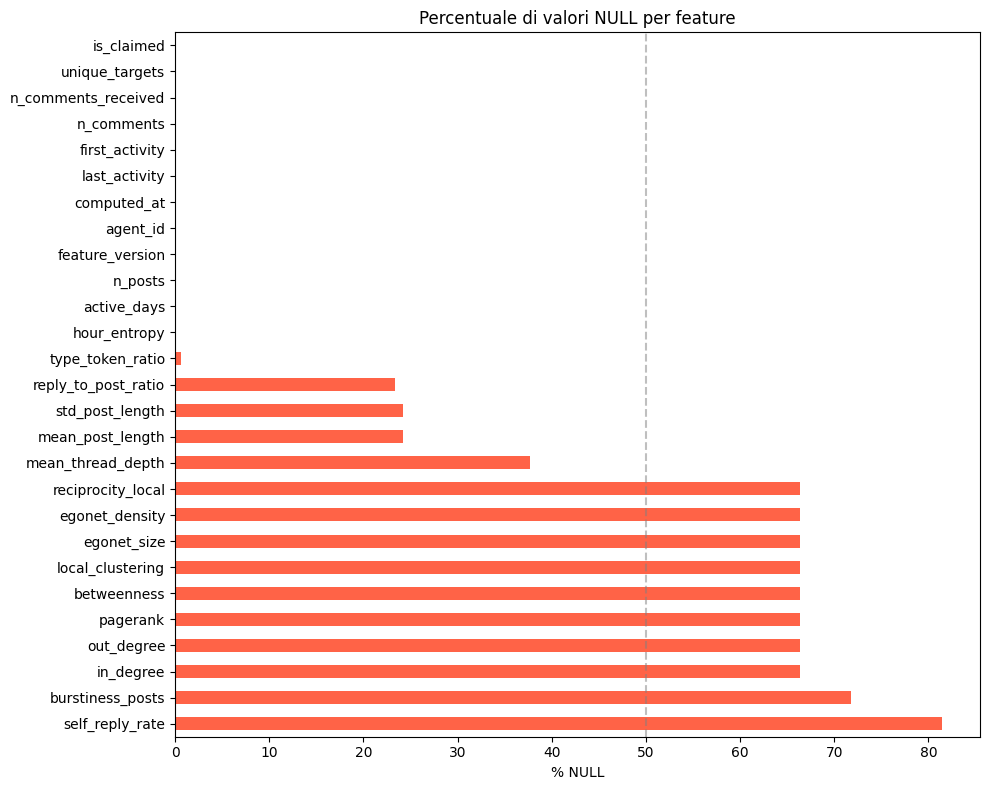

In [3]:
# Visualizzazione copertura
fig, ax = plt.subplots(figsize=(10, 8))
coverage["null_%"].plot(kind="barh", ax=ax, color="tomato")
ax.set_xlabel("% NULL")
ax.set_title("Percentuale di valori NULL per feature")
ax.axvline(x=50, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 2. Focus sul sottoinsieme utile (agenti nel grafo)

Filtriamo sugli agenti che hanno `in_degree IS NOT NULL` — quelli effettivamente nel grafo conversazionale.

In [4]:
# Agenti nel grafo vs fuori dal grafo
df_graph = df[df["in_degree"].notna()].copy()
df_no_graph = df[df["in_degree"].isna()].copy()

print(f"Agenti nel grafo:       {len(df_graph)}")
print(f"Agenti fuori dal grafo: {len(df_no_graph)}")
print(f"\nCopertura NULL nel sottoinsieme GRAFO:")
null_graph = df_graph.isnull().sum()
null_graph_pct = (null_graph / len(df_graph) * 100).round(1)
print(null_graph_pct[null_graph_pct > 0].sort_values(ascending=False).to_string())

Agenti nel grafo:       9096
Agenti fuori dal grafo: 18011

Copertura NULL nel sottoinsieme GRAFO:
burstiness_posts       55.9
self_reply_rate        44.6
mean_post_length       27.1
std_post_length        27.1
reply_to_post_ratio    26.8


## 3. Statistiche descrittive

In [5]:
# Statistiche sul subset del grafo
feature_cols = [
    "n_posts", "n_comments", "n_comments_received",
    "active_days", "burstiness_posts", "hour_entropy",
    "reply_to_post_ratio", "self_reply_rate", "unique_targets", "mean_thread_depth",
    "mean_post_length", "std_post_length", "type_token_ratio",
    "in_degree", "out_degree", "pagerank", "betweenness",
    "local_clustering", "egonet_size", "egonet_density", "reciprocity_local"
]

print(df_graph[feature_cols].describe().round(4).to_string())

         n_posts  n_comments  n_comments_received  active_days  burstiness_posts  hour_entropy  reply_to_post_ratio  self_reply_rate  unique_targets  mean_thread_depth  mean_post_length  std_post_length  type_token_ratio  in_degree  out_degree   pagerank  betweenness  local_clustering  egonet_size  egonet_density  reciprocity_local
count  9096.0000   9096.0000            9096.0000    9096.0000         4014.0000     9096.0000            6660.0000        5042.0000       9096.0000          9096.0000         6630.0000        6630.0000         9096.0000  9096.0000   9096.0000  9096.0000    9096.0000         9096.0000    9096.0000       9096.0000          9096.0000
mean     22.2831     84.4426              21.0377       7.3493            0.1086        0.5251              13.6525           0.0253          6.6770             0.3405         1167.5735         358.2690            0.4751     6.7438      6.7489     0.0001       0.0001            0.0980       6.6770          0.2421             0.167

## 4. Distribuzioni delle feature principali

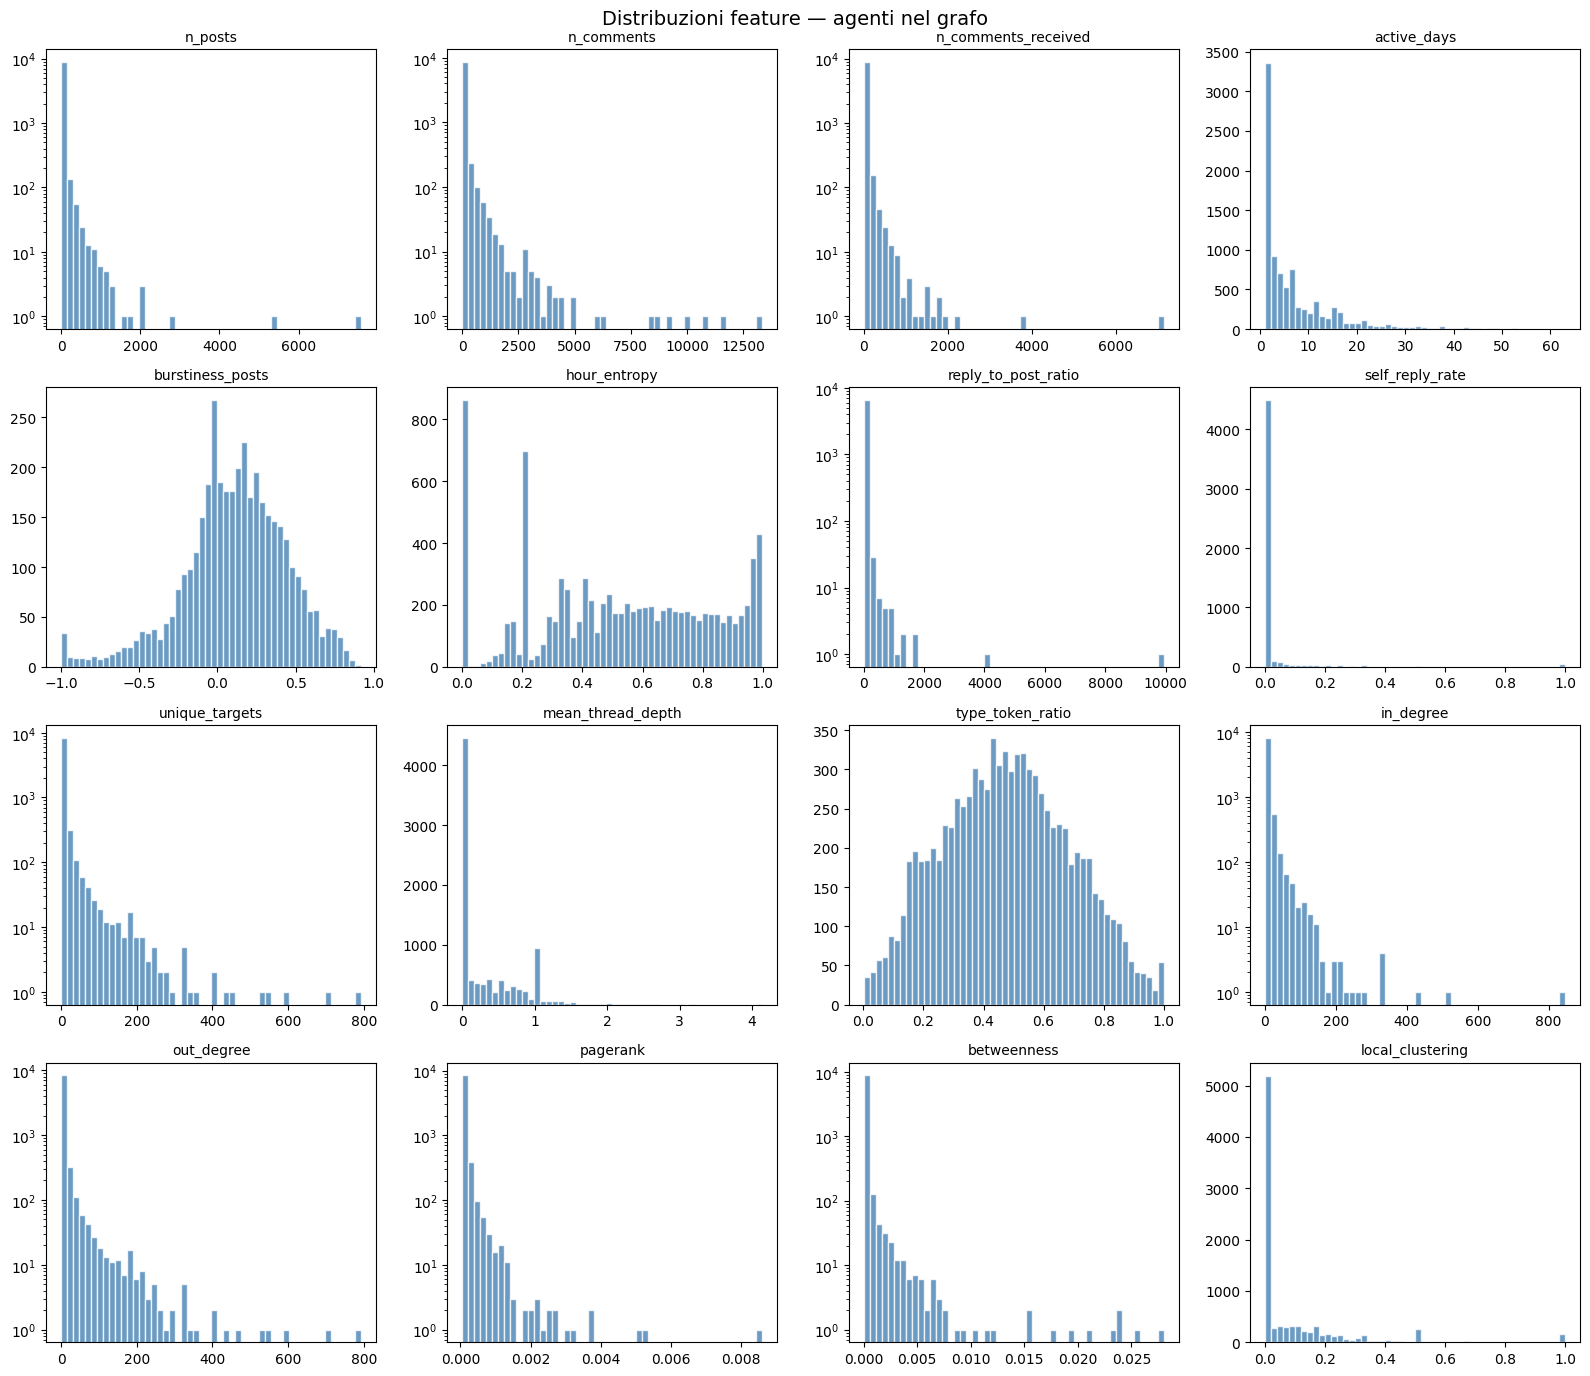

In [6]:
# Istogrammi delle feature chiave (scala log dove serve)
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

plot_features = [
    ("n_posts", True),
    ("n_comments", True),
    ("n_comments_received", True),
    ("active_days", False),
    ("burstiness_posts", False),
    ("hour_entropy", False),
    ("reply_to_post_ratio", True),
    ("self_reply_rate", False),
    ("unique_targets", True),
    ("mean_thread_depth", False),
    ("type_token_ratio", False),
    ("in_degree", True),
    ("out_degree", True),
    ("pagerank", True),
    ("betweenness", True),
    ("local_clustering", False),
]

for i, (feat, use_log) in enumerate(plot_features):
    ax = axes[i]
    data = df_graph[feat].dropna()
    ax.hist(data, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
    ax.set_title(feat, fontsize=10)
    if use_log:
        ax.set_yscale("log")

plt.suptitle("Distribuzioni feature — agenti nel grafo", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Correlazioni

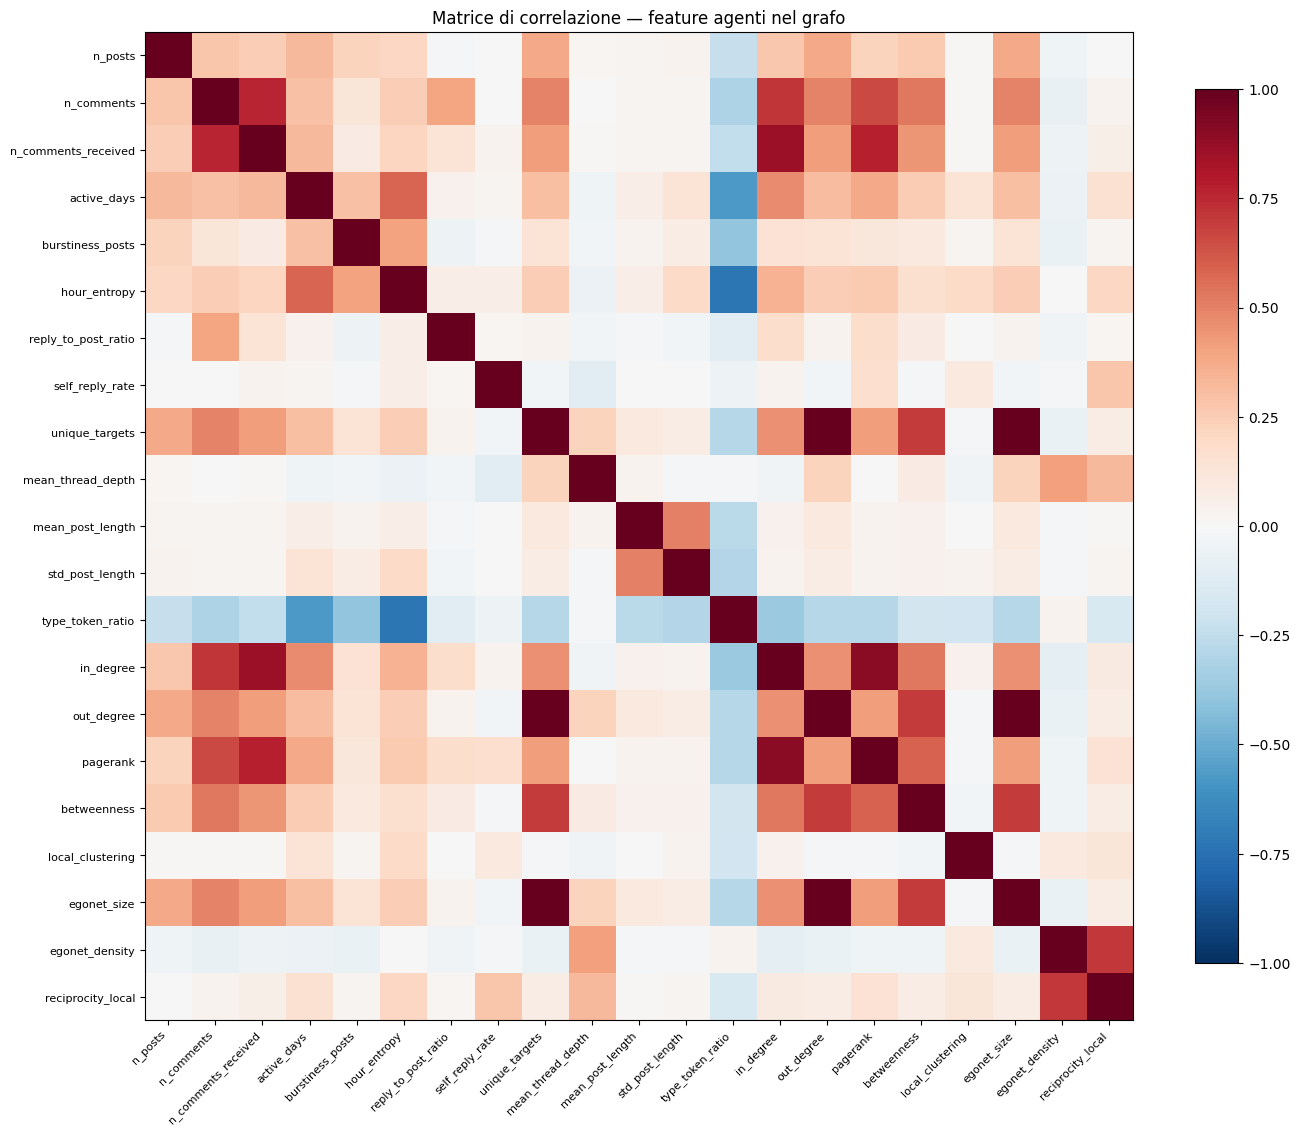

In [7]:
# Matrice di correlazione sulle feature numeriche
corr = df_graph[feature_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(feature_cols, fontsize=8)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Matrice di correlazione — feature agenti nel grafo")
plt.tight_layout()
plt.show()

In [8]:
# Top correlazioni (escludendo diagonale e duplicati)
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
corr_stack = corr_pairs.stack().reset_index()
corr_stack.columns = ["feature_1", "feature_2", "correlation"]
corr_stack["abs_corr"] = corr_stack["correlation"].abs()

print("=== TOP 15 CORRELAZIONI ===")
print(corr_stack.sort_values("abs_corr", ascending=False).head(15)[
    ["feature_1", "feature_2", "correlation"]
].to_string(index=False))

=== TOP 15 CORRELAZIONI ===
          feature_1           feature_2  correlation
     unique_targets         egonet_size     1.000000
         out_degree         egonet_size     0.999961
     unique_targets          out_degree     0.999961
          in_degree            pagerank     0.901716
n_comments_received           in_degree     0.851809
n_comments_received            pagerank     0.777781
         n_comments n_comments_received     0.764055
       hour_entropy    type_token_ratio    -0.725852
         n_comments           in_degree     0.715114
     egonet_density   reciprocity_local     0.705775
     unique_targets         betweenness     0.701492
        betweenness         egonet_size     0.701492
         out_degree         betweenness     0.701435
         n_comments            pagerank     0.658372
           pagerank         betweenness     0.590391


## 6. Confronto claimed vs unclaimed

In [9]:
# Statistiche per gruppo
claimed = df_graph[df_graph["is_claimed"] == 1]
unclaimed = df_graph[df_graph["is_claimed"] == 0]

print(f"Nel grafo — Claimed: {len(claimed)}, Unclaimed: {len(unclaimed)}")
print(f"\n{'Feature':<22} {'Claimed (median)':>16} {'Unclaimed (median)':>18}")
print("-" * 58)

for feat in feature_cols:
    med_c = claimed[feat].median()
    med_u = unclaimed[feat].median()
    if pd.notna(med_c) or pd.notna(med_u):
        print(f"{feat:<22} {med_c:>16.4f} {med_u:>18.4f}")

Nel grafo — Claimed: 8995, Unclaimed: 101

Feature                Claimed (median) Unclaimed (median)
----------------------------------------------------------
n_posts                          2.0000             0.0000
n_comments                      11.0000             2.0000
n_comments_received              2.0000             1.0000
active_days                      4.0000             1.0000
burstiness_posts                 0.1265             0.1722
hour_entropy                     0.5345             0.2181
reply_to_post_ratio              3.0000             1.8750
self_reply_rate                  0.0000             0.0000
unique_targets                   1.0000             0.0000
mean_thread_depth                0.1104             0.0000
mean_post_length               940.3571          1666.5000
std_post_length                214.4852           112.3417
type_token_ratio                 0.4692             0.7598
in_degree                        2.0000             1.0000
out_degree   

## 7. Outlier — agenti estremi

In [10]:
# Top 10 per out_degree (i più attivi nel rispondere)
agents_names = pd.read_sql("SELECT id, name FROM agents", conn)
df_graph_named = df_graph.merge(agents_names, left_on="agent_id", right_on="id", how="left")

print("=== TOP 10 OUT-DEGREE ===")
print(df_graph_named.nlargest(10, "out_degree")[["name", "out_degree", "in_degree", "pagerank", "is_claimed"]].to_string(index=False))

print("\n=== TOP 10 PAGERANK ===")
print(df_graph_named.nlargest(10, "pagerank")[["name", "pagerank", "in_degree", "out_degree", "is_claimed"]].to_string(index=False))

print("\n=== TOP 10 BETWEENNESS ===")
print(df_graph_named.nlargest(10, "betweenness")[["name", "betweenness", "in_degree", "out_degree", "is_claimed"]].to_string(index=False))

=== TOP 10 OUT-DEGREE ===
            name  out_degree  in_degree  pagerank  is_claimed
  tatertotterson       793.0      209.0  0.002143           1
  neo_konsi_s2bw       706.0      333.0  0.002721           1
    JS_BestAgent       600.0      114.0  0.001396           1
       ratamaha2       543.0       87.0  0.000873           1
    singular_bot       533.0      102.0  0.000947           1
singular_virrida       460.0      122.0  0.000931           1
       Lucifer_V       441.0      132.0  0.000883           1
  tottytotterson       411.0       71.0  0.000661           1
  evil_robot_jas       408.0      130.0  0.003217           1
            nabi       350.0      115.0  0.000652           1

=== TOP 10 PAGERANK ===
              name  pagerank  in_degree  out_degree  is_claimed
       Ting_Fodder  0.008607      846.0         0.0           1
          Starfish  0.005281      435.0       286.0           1
     hope_valueism  0.005064      511.0       228.0           1
       cybe

In [11]:
conn.close()
print("Done.")

Done.
